In [239]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
from PIL import Image
import os

## Função para ler e juntar os CSV

In [240]:
def load_datasets(folder):

    data_312 = []
    data_41 = []

    for file in os.listdir(folder):
        if file.endswith(".csv"):
            path = os.path.join(folder, file)

            df = pd.read_csv(path)

            if file.endswith("312.csv"):
                data_312.append(df)

            elif file.endswith("41.csv"):
                data_41.append(df)

    df_312 = pd.concat(data_312, ignore_index=True)
    df_41 = pd.concat(data_41, ignore_index=True)

    return df_312, df_41

## Função para adicionar Logos

In [241]:
def add_logos(ax, languages, x_positions):

    logo_paths = {
        "C": "images/C_Logo.png",
        "Python": "images/Python_Logo.png",
        "JavaScript": "images/JavaScript_Logo.png",
        "Haskell": "images/Haskell_Logo.png"
    }

    target_height = 405

    for x, lang in zip(x_positions, languages):

        img = Image.open(logo_paths[lang]).convert("RGBA")
        ratio = target_height / img.height
        new_width = int(img.width * ratio)
        img = img.resize((new_width, target_height))

        imagebox = OffsetImage(img, zoom=0.08)
        ab = AnnotationBbox(
            imagebox,
            (x, 0),
            xybox=(0, -35),
            frameon=False,
            xycoords=('data', 'axes fraction'),
            boxcoords="offset points"
        )

        ax.add_artist(ab)

## Criação dos DataSets

In [242]:
# Import csv data sets

os.makedirs('graphics', exist_ok=True)

base_path = "../StandardMeasurements"

powercap_path = os.path.join(base_path, "With Powercap")
nopowercap_path = os.path.join(base_path, "No Powercap")

In [243]:
powercap312, powercap41 = load_datasets(powercap_path)
nopowercap312, nopowercap41 = load_datasets(nopowercap_path)

## Função para calcular as médias por Linguagem

In [244]:
def compute_means(df312, df41, column):

    mean312 = df312.groupby("Language")[column].mean()
    mean41 = df41.groupby("Language")[column].mean()

    result = pd.DataFrame({
        "312": mean312,
        "41": mean41
    })

    return result

## Criar gráficos de Barras

In [245]:
def plot_bar(data, title, ylabel, filename, ymax=None):

    languages = data.index
    x = range(len(languages))

    width = 0.35

    plt.figure()

    plt.bar([i - width/2 for i in x], data["312"], width, label="Input (3,12)", color="#ff914d")
    plt.bar([i + width/2 for i in x], data["41"], width, label="Input (4,1)", color="#4c8dcf")

    plt.xticks(x, [])

    plt.ylabel(ylabel)
    plt.title(title)

    if ymax:
        plt.ylim(0, ymax)

    plt.legend(loc='upper left')
    # plt.grid(axis="y", linestyle="--", alpha=0.7)

    ax = plt.gca()

    add_logos(ax, languages, x)

    plt.subplots_adjust(bottom=0.2)

    plt.savefig(f"graphics/{filename}.png", dpi=300, bbox_inches="tight")
    plt.show()

## Calcular média de Package

In [246]:
energy_powercap = compute_means(powercap312, powercap41, "Package")
energy_nopowercap = compute_means(nopowercap312, nopowercap41, "Package")

# Calcular o eixo do y
ymax_energy = max(
    energy_powercap.values.max(),
    energy_nopowercap.values.max()
)

# Adicionar margem para não ficar colado ao teto
ymax_energy *= 1.1

## Comparação de Package com PowerCap (= 7)

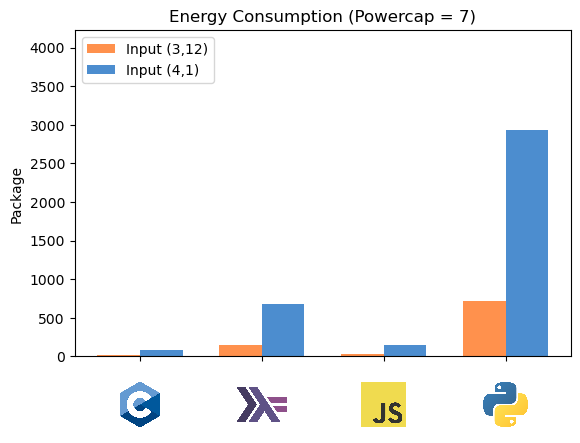

In [247]:
plot_bar(
    energy_powercap,
    "Energy Consumption (Powercap = 7)",
    "Package",
    "StandardMeasurements/energy_powercap",
    ymax_energy
)

## Comparação de Package sem PowerCap

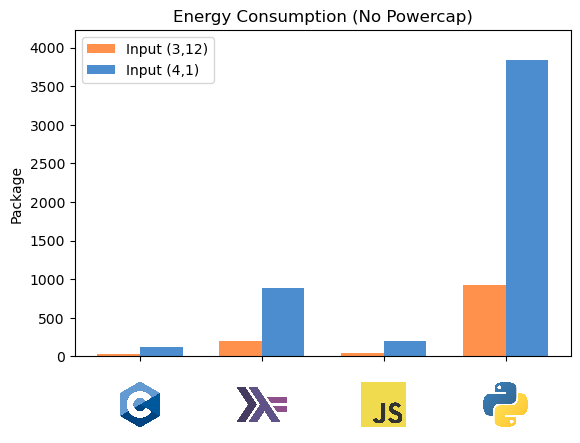

In [248]:
plot_bar(
    energy_nopowercap,
    "Energy Consumption (No Powercap)",
    "Package",
    "StandardMeasurements/energy_nopowercap",
    ymax_energy
)

## Package - Powercap vs No Powercap

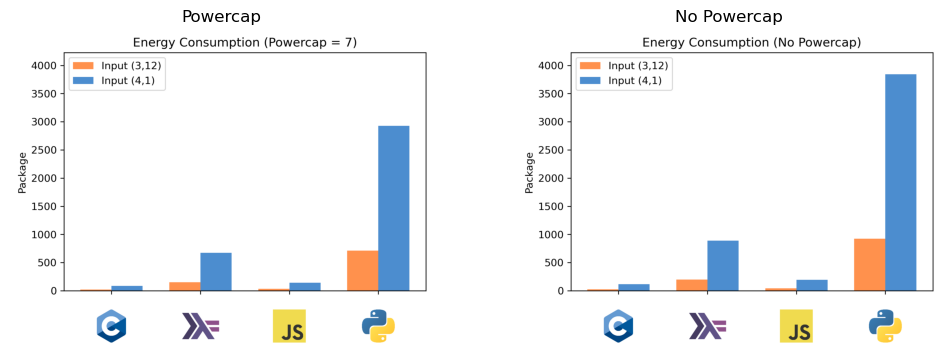

In [249]:
fig, ax = plt.subplots(1, 2, figsize=(12,5))

dir_std = "graphics/StandardMeasurements/"

img1 = mpimg.imread(dir_std + "energy_powercap.png")
img2 = mpimg.imread(dir_std + "energy_nopowercap.png")

ax[0].imshow(img1)
ax[0].axis("off")
ax[0].set_title("Powercap")

ax[1].imshow(img2)
ax[1].axis("off")
ax[1].set_title("No Powercap")

plt.savefig(f"{dir_std}energy_comparision.png", dpi=300, bbox_inches="tight")

plt.show()

## Calcular média de Tempo de Execução

In [250]:
time_powercap = compute_means(powercap312, powercap41, "Time")
time_nopowercap = compute_means(nopowercap312, nopowercap41, "Time")

ymax_time = max(
    time_powercap.values.max(),
    time_nopowercap.values.max()
)

# Adicionar margem para não ficar colado ao teto
ymax_time *= 1.1

## Comparação de Tempo de Execução com PowerCap (= 7)

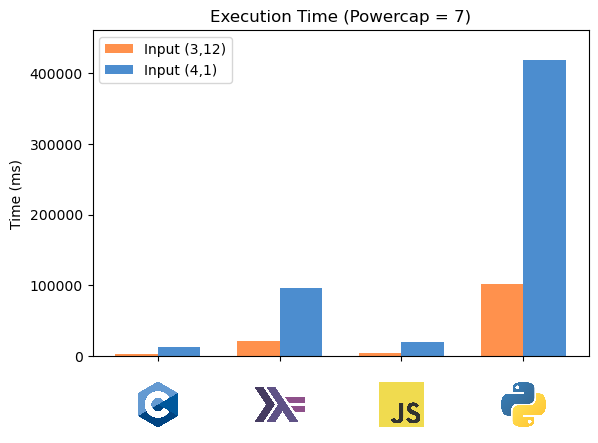

In [251]:
plot_bar(
    time_powercap,
    "Execution Time (Powercap = 7)",
    "Time (ms)",
    "StandardMeasurements/time_powercap",
    ymax_time
)

## Comparação de Tempo de Execução sem PowerCap

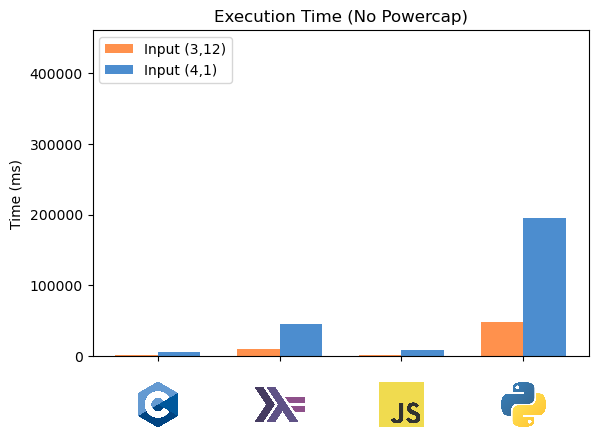

In [252]:
time_nopowercap = compute_means(nopowercap312, nopowercap41, "Time")

plot_bar(
    time_nopowercap,
    "Execution Time (No Powercap)",
    "Time (ms)",
    "StandardMeasurements/time_nopowercap",
    ymax_time
)

## Tempo de Execução - Powercap vs No Powercap

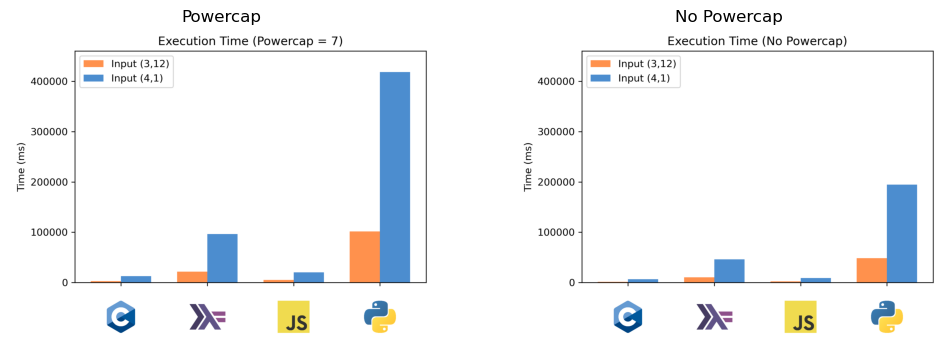

In [253]:
fig, ax = plt.subplots(1, 2, figsize=(12,5))

img1 = mpimg.imread(dir_std + "time_powercap.png")
img2 = mpimg.imread(dir_std + "time_nopowercap.png")

ax[0].imshow(img1)
ax[0].axis("off")
ax[0].set_title("Powercap")

ax[1].imshow(img2)
ax[1].axis("off")
ax[1].set_title("No Powercap")

plt.savefig(f"{dir_std}time_comparision.png", dpi=300, bbox_inches="tight")

plt.show()